# Car model from any angle

`car_brand_predictor.ipynb` recognises the **brand** from a front photo. This notebook adds the second step: for each of its 33 brands, a classifier that recognises the **car model** (BMW 3 Series, X5, …) from photos taken at **any angle**.

At prediction time (the dashboard), the brand model looks at the front photo, for example 95% BMW and 5% Mercedes-Benz. Only the BMW and Mercedes-Benz model classifiers then look at all the photos of the car.

**Saving time and computing.** Training 33 full networks would take days on the Mac. Instead:
1. One pretrained EfficientNetB0 turns every photo into 1,280 numbers that describe it (its **features**). This is the slow part, and it's done once and saved.
2. Each brand's model classifier is a small network trained on those numbers. That takes minutes per brand.

**Nothing runs twice.** Features, the photo index and every brand's classifier are saved in `models/`. Running the notebook again loads them instead of recomputing.

Steps:
1. Build the photo index from the full DVM-CAR image set (all angles)
2. Split by advert, consistent with the brand model's split
3. Pick the feature extractor: ImageNet EfficientNetB0 or the backbone of our brand model
4. Extract the features of every photo
5. Train one car-model classifier per brand
6. Evaluate: per photo, per angle, per car (several photos), and the full brand → model pipeline

In [22]:
import hashlib
import json
import os
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from PIL import Image

DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "resized_DVM"
MODELS_DIR = Path("models")
FEATURES_DIR = MODELS_DIR / "features"
HEADS_DIR = MODELS_DIR / "model_heads"
INDEX_PATH = FEATURES_DIR / "photo_index.csv"
FEATURES_PATH = FEATURES_DIR / "features.npy"
BRAND_MODEL_PATH = MODELS_DIR / "efficientnet_b0.keras"

BRAND_MERGES = {"Abarth": "Fiat", "DS": "Citroen"}
MIN_PHOTOS_PER_MODEL = 300
MAX_PER_MODEL_AND_ANGLE = None  # None = keep every photo
IMAGE_SIZE = 224
BATCH_SIZE = 64
SEED = 42

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
HEADS_DIR.mkdir(parents=True, exist_ok=True)

# The 33 brands of the brand model, in its label order
BRANDS = sorted(pd.read_csv(DATA_DIR / "index.csv")["brand"].unique())
print(f"{len(BRANDS)} brands | GPU: {tf.config.list_physical_devices('GPU')}")

33 brands | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Photo index

Same rules as the brand model and the fronts: read brand, model, advert and angle from `Image_table.csv`, merge Abarth into Fiat and DS into Citroen, drop photos that failed the dataset's quality check, remove unreadable photos and duplicates.

Only the 33 brands the brand model knows are kept, and only car models with at least 300 photos. Rarer models don't have enough photos to learn from (together they're about 2% of the photos).

Checking and hashing 1.4 million photos takes several minutes; the result is saved to `models/features/photo_index.csv` and reused next time.

In [23]:
def check(relative_path):
    """Return the MD5 of the file if it decodes as an image, otherwise None."""
    path = IMAGES_DIR / relative_path
    try:
        data = path.read_bytes()
        with Image.open(path) as img:
            img.load()
        return hashlib.md5(data).hexdigest()
    except Exception:
        return None


def build_index():
    table = pd.read_csv(DATA_DIR / "Image_table.csv", skipinitialspace=True)
    fields = table["Image_name"].str.split("$$", regex=False)
    table = table[fields.str.len() == 7]
    fields = fields[table.index]

    df = pd.DataFrame({
        "path": fields.str[0] + "/" + fields.str[1] + "/" + fields.str[2] + "/" + fields.str[3] + "/" + fields.str.join("$$"),
        "brand": fields.str[0].replace(BRAND_MERGES),
        "model": fields.str[1],
        "year": fields.str[2].astype(int),
        "advert_id": fields.str[4] + "$$" + fields.str[5],
        "angle": table["Predicted_viewpoint"] % 360,
        "quality": table["Quality_check"],
    })
    print(f"{len(df):,} photos in Image_table.csv")

    df = df[(df["quality"] != "N") & df["brand"].isin(BRANDS)].drop(columns="quality")
    counts = df.groupby(["brand", "model"])["path"].transform("size")
    df = df[counts >= MIN_PHOTOS_PER_MODEL]
    print(f"{len(df):,} photos of the {len(BRANDS)} brands, models with at least {MIN_PHOTOS_PER_MODEL} photos")

    if MAX_PER_MODEL_AND_ANGLE is not None:
        df = df.sample(frac=1, random_state=SEED).groupby(["brand", "model", "angle"]).head(MAX_PER_MODEL_AND_ANGLE)
        print(f"{len(df):,} photos after keeping at most {MAX_PER_MODEL_AND_ANGLE} per model and angle")

    with ThreadPoolExecutor(max_workers=8) as pool:
        df["md5"] = list(pool.map(check, df["path"], chunksize=512))
    print(f"{df['md5'].isna().sum():,} missing or unreadable photos removed")
    df = df.dropna(subset=["md5"])

    # a photo filed under two different car models can't be trusted: drop every copy
    labels_per_file = df.groupby("md5")[["brand", "model"]].nunique().max(axis=1)
    conflicting = labels_per_file[labels_per_file > 1].index
    print(f"{df['md5'].isin(conflicting).sum():,} photos removed because the same file has two different labels")
    df = df[~df["md5"].isin(conflicting)]
    n_before = len(df)
    df = df.drop_duplicates(subset="md5")
    print(f"{n_before - len(df):,} duplicate copies removed")
    return df.drop(columns="md5").sort_values(["brand", "model", "path"]).reset_index(drop=True)


if INDEX_PATH.exists():
    photos = pd.read_csv(INDEX_PATH)
    print(f"Loaded {INDEX_PATH}")
else:
    photos = build_index()
print(f"{len(photos):,} photos, {photos.groupby(['brand', 'model']).ngroups} car models")

1,451,784 photos in Image_table.csv
1,373,324 photos of the 33 brands, models with at least 300 photos
0 missing or unreadable photos removed
4,795 photos removed because the same file has two different labels
16,710 duplicate copies removed
1,351,819 photos, 421 car models


## 2. Split by advert

As always, all photos of one advert (one car) go to the same set, 80 / 10 / 10.

One extra rule: many of these photos' adverts were also used for the brand model. An advert that was in the brand model's **validation** or **test** set goes to the same set here. Otherwise the full-pipeline test in section 6 would use cars the brand model trained on, and look better than it is.

In [24]:
if "split" not in photos.columns:
    brand_test = set(pd.read_csv(MODELS_DIR / "test_predictions.csv")["advert_id"])
    brand_val = set(pd.read_csv(MODELS_DIR / "small_cnn_val_predictions.csv")["advert_id"])

    adverts = photos.groupby("advert_id")[["brand", "model"]].first().sample(frac=1, random_state=SEED)
    position = adverts.groupby(["brand", "model"]).cumcount() / adverts.groupby(["brand", "model"])["brand"].transform("size")
    adverts["split"] = np.select([position < 0.1, position < 0.2], ["test", "val"], default="train")
    adverts.loc[adverts.index.isin(brand_val), "split"] = "val"
    adverts.loc[adverts.index.isin(brand_test), "split"] = "test"

    photos["split"] = photos["advert_id"].map(adverts["split"])
    photos.to_csv(INDEX_PATH, index=False)
    print(f"Saved {INDEX_PATH}")

print(photos["split"].value_counts().to_string())
print(f"\n{(photos.groupby('advert_id')['split'].nunique() > 1).sum()} adverts appear in more than one split")
print(photos.groupby("split")["angle"].value_counts(normalize=True).unstack().map("{:.0%}".format).to_string())

Saved models/features/photo_index.csv
split
train    1026733
test      163370
val       161716

0 adverts appear in more than one split
angle  0    45   90   135  180  225  270  315
split                                        
test   16%   9%  13%   9%  16%  15%  10%  10%
train  16%  10%  14%  10%  16%  15%  10%  10%
val    17%   9%  14%   9%  17%  15%  10%  10%


## 3. Pick the feature extractor

Two candidates, both EfficientNetB0 without its last layer:
- **ImageNet**: trained on 1.3 million everyday photos. General-purpose.
- **Our brand model's backbone**: the same network after fine-tuning on car fronts. It knows cars better, but only saw fronts, and was trained to tell brands apart, not models.

Quick test on three brands (BMW, Audi, Ford), with at most 150 photos per model for training: extract features with each, train a small classifier, compare validation accuracy. The winner is used for everything else.

In [25]:
def load_image(path):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    return tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))


def photo_dataset(paths):
    full_paths = [str(IMAGES_DIR / p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices(full_paths)
    return ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def make_extractor(which):
    """EfficientNetB0 (224×224 images, pixels 0–255) → 1,280 features per photo."""
    if which == "imagenet":
        base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    else:
        base = keras.models.load_model(BRAND_MODEL_PATH).get_layer("efficientnetb0")
    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    outputs = layers.GlobalAveragePooling2D()(base(inputs, training=False))
    return keras.Model(inputs, outputs, name=f"features_{which}")


def make_head(n_features, n_classes):
    """The small car-model classifier trained on top of the features."""
    head = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes),
    ])
    head.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return head


def fit_head(x_train, y_train, x_val, y_val, n_classes, verbose=0):
    counts = np.bincount(y_train, minlength=n_classes)
    class_weight = {i: len(y_train) / (n_classes * c) for i, c in enumerate(counts) if c > 0}
    head = make_head(x_train.shape[1], n_classes)
    head.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=60,
        batch_size=256,
        class_weight=class_weight,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=verbose,
    )
    return head


trial = photos[photos["brand"].isin(["BMW", "Audi", "Ford"]) & photos["split"].isin(["train", "val"])]
trial = trial.groupby(["brand", "model", "split"], group_keys=False).head(150)
print(f"Trial: {len(trial):,} photos, {trial.groupby(['brand', 'model']).ngroups} car models")

trial_scores = {}
for which in ["imagenet", "brand_model"]:
    t = time.time()
    extractor = make_extractor(which)
    features = extractor.predict(photo_dataset(trial["path"]), verbose=0)
    speed = len(trial) / (time.time() - t)

    accuracies = []
    for brand, part in trial.groupby("brand"):
        classes = sorted(part["model"].unique())
        y = part["model"].map({m: i for i, m in enumerate(classes)}).values
        x = features[trial.index.get_indexer(part.index)]
        train, val = (part["split"] == "train").values, (part["split"] == "val").values
        head = fit_head(x[train], y[train], x[val], y[val], len(classes))
        accuracies.append(head.evaluate(x[val], y[val], verbose=0)[1])
    trial_scores[which] = np.mean(accuracies)
    print(f"{which}: validation accuracy {trial_scores[which]:.1%} (mean of 3 brands), {speed:.0f} photos/s")

BACKBONE = max(trial_scores, key=trial_scores.get)
print(f"\nFeature extractor: {BACKBONE}")

Trial: 22,982 photos, 80 car models
imagenet: validation accuracy 57.5% (mean of 3 brands), 225 photos/s
brand_model: validation accuracy 57.6% (mean of 3 brands), 253 photos/s

Feature extractor: brand_model


## 4. Extract the features of every photo

Every photo goes through the extractor once. The 1,280 numbers per photo are stored as 16-bit floats in `models/features/features.npy` (row *i* = photo *i* of `photo_index.csv`).

This is the long step. It works in chunks of 20,000 photos and records its progress, so if it's interrupted, running the cell again continues where it stopped.

In [26]:
FEATURES_INFO = FEATURES_DIR / "features_info.json"
CHUNK = 20_000

info = json.loads(FEATURES_INFO.read_text()) if FEATURES_INFO.exists() else {"backbone": BACKBONE, "done": 0}
assert info["backbone"] == BACKBONE, f"features.npy was made with {info['backbone']}; delete models/features/features* to redo it"

mode = "r+" if FEATURES_PATH.exists() else "w+"
features = np.lib.format.open_memmap(FEATURES_PATH, mode=mode, dtype=np.float16, shape=(len(photos), 1280))

if info["done"] < len(photos):
    extractor = make_extractor(BACKBONE)
    t = time.time()
    for start in range(info["done"], len(photos), CHUNK):
        end = min(start + CHUNK, len(photos))
        features[start:end] = extractor.predict(photo_dataset(photos["path"].iloc[start:end]), verbose=0)
        features.flush()
        info["done"] = end
        FEATURES_INFO.write_text(json.dumps(info))
        rate = (end - start) / (time.time() - t)
        print(f"{end:,} / {len(photos):,} photos ({rate:.0f}/s, about {(len(photos) - end) / rate / 60:.0f} min left)", flush=True)
        t = time.time()

print(f"Features ready: {features.shape[0]:,} photos × {features.shape[1]} numbers ({BACKBONE})")

20,000 / 1,351,819 photos (236/s, about 94 min left)
40,000 / 1,351,819 photos (252/s, about 87 min left)
60,000 / 1,351,819 photos (251/s, about 86 min left)
80,000 / 1,351,819 photos (250/s, about 85 min left)
100,000 / 1,351,819 photos (257/s, about 81 min left)
120,000 / 1,351,819 photos (272/s, about 75 min left)
140,000 / 1,351,819 photos (270/s, about 75 min left)
160,000 / 1,351,819 photos (265/s, about 75 min left)
180,000 / 1,351,819 photos (260/s, about 75 min left)
200,000 / 1,351,819 photos (266/s, about 72 min left)
220,000 / 1,351,819 photos (265/s, about 71 min left)
240,000 / 1,351,819 photos (264/s, about 70 min left)
260,000 / 1,351,819 photos (261/s, about 70 min left)
280,000 / 1,351,819 photos (252/s, about 71 min left)
300,000 / 1,351,819 photos (253/s, about 69 min left)
320,000 / 1,351,819 photos (282/s, about 61 min left)
340,000 / 1,351,819 photos (280/s, about 60 min left)
360,000 / 1,351,819 photos (279/s, about 59 min left)
380,000 / 1,351,819 photos (271/

## 5. One car-model classifier per brand

For each brand: its photos' features go into a small network (Dense 256 → Dropout → one output per car model). Class weights balance common and rare models, and early stopping keeps the best epoch by validation loss.

Each classifier is saved to `models/model_heads/<brand>.keras`, with the list of its car models in `<brand>_classes.json`. A brand that already has a saved classifier is skipped.

In [27]:
def brand_data(brand):
    part = photos[photos["brand"] == brand]
    classes = sorted(part["model"].unique())
    y = part["model"].map({m: i for i, m in enumerate(classes)}).values
    x = np.asarray(features[part.index.values], dtype=np.float32)
    return part, classes, x, y


for brand in BRANDS:
    head_path = HEADS_DIR / f"{brand}.keras"
    if head_path.exists():
        continue
    t = time.time()
    part, classes, x, y = brand_data(brand)
    train, val = (part["split"] == "train").values, (part["split"] == "val").values
    head = fit_head(x[train], y[train], x[val], y[val], len(classes))
    head.save(head_path)
    (HEADS_DIR / f"{brand}_classes.json").write_text(json.dumps(classes))
    print(f"{brand}: {len(classes)} models, {train.sum():,} training photos, "
          f"validation accuracy {head.evaluate(x[val], y[val], verbose=0)[1]:.1%} ({time.time() - t:.0f}s)", flush=True)

print(f"{len(list(HEADS_DIR.glob('*.keras')))} brand classifiers in {HEADS_DIR}")

Alfa Romeo: 5 models, 3,942 training photos, validation accuracy 94.6% (6s)
Audi: 33 models, 87,940 training photos, validation accuracy 58.6% (53s)
BMW: 27 models, 71,241 training photos, validation accuracy 70.9% (59s)
Bentley: 3 models, 4,970 training photos, validation accuracy 93.5% (4s)
Chevrolet: 4 models, 1,715 training photos, validation accuracy 95.7% (3s)
Citroen: 20 models, 35,222 training photos, validation accuracy 81.3% (17s)
Dacia: 4 models, 6,125 training photos, validation accuracy 89.4% (4s)
Fiat: 13 models, 25,042 training photos, validation accuracy 83.8% (12s)
Ford: 20 models, 106,063 training photos, validation accuracy 81.5% (62s)
Honda: 9 models, 21,920 training photos, validation accuracy 92.0% (10s)
Hyundai: 13 models, 24,548 training photos, validation accuracy 87.8% (16s)
Jaguar: 11 models, 33,215 training photos, validation accuracy 84.3% (18s)
Jeep: 4 models, 3,718 training photos, validation accuracy 87.9% (3s)
Kia: 13 models, 31,583 training photos, val

## 6. Evaluation

### 6.1 Per photo and per car, for every brand

**Per photo**: each test photo on its own, whatever its angle.
**Per car**: the dashboard sees several photos of the same car, so here the probabilities of all photos of one test advert are averaged before picking the model. This is the number that matters for the dashboard.

Here the brand is taken as known; section 6.3 tests the full pipeline. Results are saved to `models/model_heads/summary.csv` and every test prediction to `test_predictions.csv`.

In [28]:
results, summary = [], []
for brand in BRANDS:
    part, classes, x, y = brand_data(brand)
    test = (part["split"] == "test").values
    head = keras.models.load_model(HEADS_DIR / f"{brand}.keras")
    probabilities = tf.nn.softmax(head(x[test], training=False)).numpy()

    rows = part[test].copy()
    rows["predicted_model"] = [classes[i] for i in probabilities.argmax(axis=1)]
    rows["correct"] = rows["predicted_model"] == rows["model"]
    results.append(rows)

    per_car = pd.DataFrame(probabilities, index=rows["advert_id"]).groupby(level=0).mean()
    car_truth = rows.groupby("advert_id")["model"].first().loc[per_car.index]
    car_correct = np.array(classes)[per_car.values.argmax(axis=1)] == car_truth.values

    summary.append({
        "brand": brand,
        "models": len(classes),
        "test photos": test.sum(),
        "photo accuracy": rows["correct"].mean(),
        "balanced photo accuracy": rows.groupby("model")["correct"].mean().mean(),
        "test cars": len(per_car),
        "car accuracy": car_correct.mean(),
    })

test_results = pd.concat(results)
test_results.to_csv(HEADS_DIR / "test_predictions.csv", index=False)
summary = pd.DataFrame(summary).set_index("brand").sort_values("car accuracy")
summary.to_csv(HEADS_DIR / "summary.csv")

print(f"All brands: photo accuracy {test_results['correct'].mean():.1%}, "
      f"car accuracy {np.average(summary['car accuracy'], weights=summary['test cars']):.1%}")
summary.style.format({c: "{:.1%}" for c in ["photo accuracy", "balanced photo accuracy", "car accuracy"]})

All brands: photo accuracy 78.5%, car accuracy 91.4%


,models,test photos,photo accuracy,balanced photo accuracy,test cars,car accuracy
brand,,,,,,
Audi,33,17354,46.4%,52.7%,2773,62.2%
BMW,27,13402,64.5%,65.0%,2126,84.9%
Land Rover,12,4385,72.2%,69.3%,949,84.9%
Mercedes-Benz,22,5938,71.9%,71.8%,945,87.4%
Porsche,8,3693,71.4%,74.7%,591,88.0%
Lexus,13,1626,74.0%,71.5%,279,88.5%
Citroen,20,6491,82.3%,78.4%,1169,93.4%
Volkswagen,25,11261,81.0%,80.3%,1909,94.0%
Maserati,4,439,86.6%,85.6%,70,94.3%


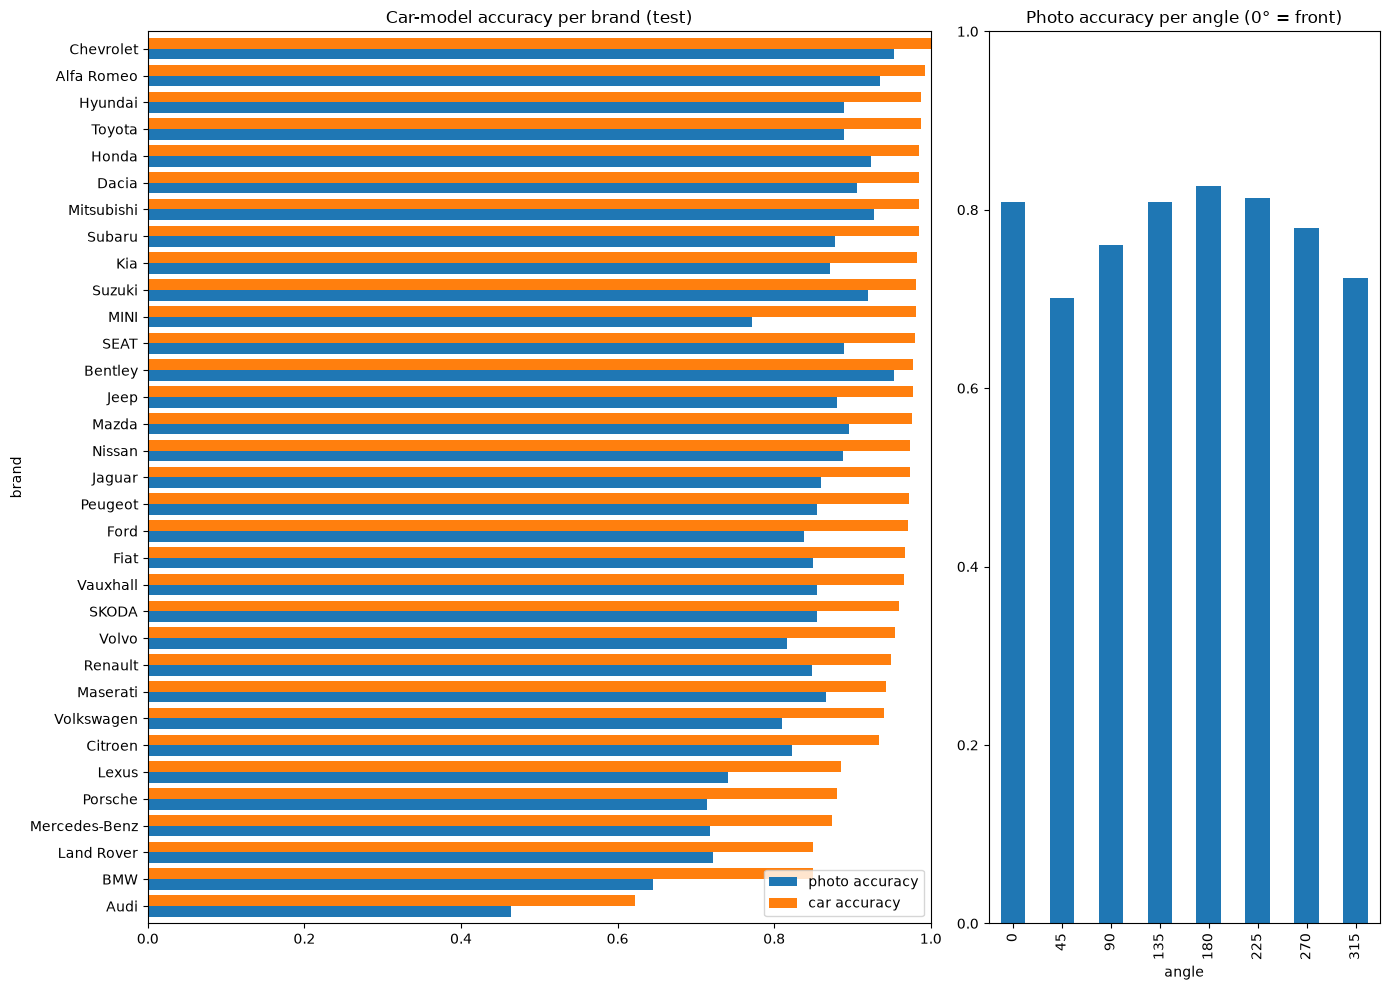

In [29]:
fig, (ax_brand, ax_angle) = plt.subplots(1, 2, figsize=(14, 10), gridspec_kw={"width_ratios": [2, 1]})
summary[["photo accuracy", "car accuracy"]].plot.barh(ax=ax_brand, width=0.8, title="Car-model accuracy per brand (test)")
ax_brand.set_xlim(0, 1)
test_results.groupby("angle")["correct"].mean().plot.bar(ax=ax_angle, title="Photo accuracy per angle (0° = front)")
ax_angle.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 6.2 Most common mistakes

Which car models get mixed up? Pairs from the same family (a Coupé and a Gran Coupé, a car and its estate version) are the expected ones.

In [30]:
mistakes = test_results[~test_results["correct"]].groupby(["brand", "model", "predicted_model"]).size()
print(mistakes.sort_values(ascending=False).head(20).to_string())

brand          model         predicted_model       
Vauxhall       Corsa         Astra                     454
BMW            X5            X3                        355
Ford           Focus         Mondeo                    354
Porsche        911           Cayman                    323
Land Rover     Range Rover   Range Rover Velar         318
Mercedes-Benz  E Class       C Class                   303
Fiat           500           500C                      256
BMW            1 Series      2 Series Active Tourer    235
Audi           A4 Avant      A4 Allroad                219
               A1            S1                        218
               A6 Avant      A6 Allroad                212
               Q5            Q3                        210
Volkswagen     Golf          Passat                    208
Audi           A3            Q2                        202
               A5 Cabriolet  A4 Cabriolet              201
               TT            TTS                       196
Volk

### 6.3 The full pipeline, like the dashboard

For every test car that has a front photo:
1. The **brand model** looks at the front photo.
2. The car-model classifiers of the brands with at least 5% probability (at most 3) look at **all** the car's photos, averaged.
3. Final score of each (brand, model): P(brand) × P(model | brand). The highest wins.

Correct means both the brand and the model are right. Only cars from the brand model's own test set (in `car_brand_predictor.ipynb`) are used, so none of them was used to train either step.

In [31]:
brand_model = keras.models.load_model(BRAND_MODEL_PATH)
heads = {b: keras.models.load_model(HEADS_DIR / f"{b}.keras") for b in BRANDS}
head_classes = {b: json.loads((HEADS_DIR / f"{b}_classes.json").read_text()) for b in BRANDS}

# only cars from the brand model's own test set: neither step has seen them
brand_test = set(pd.read_csv(MODELS_DIR / "test_predictions.csv")["advert_id"])
test_photos = photos[(photos["split"] == "test") & photos["advert_id"].isin(brand_test)]
fronts = test_photos[test_photos["angle"] == 0].groupby("advert_id").head(1)
brand_probabilities = tf.nn.softmax(brand_model.predict(photo_dataset(fronts["path"]), verbose=0)).numpy()


def predict_car(brand_p, car_features):
    """(brand, model, score) for one car: brand probabilities from its front, features of all its photos."""
    candidates = [i for i in brand_p.argsort()[::-1][:3] if brand_p[i] >= 0.05] or [brand_p.argmax()]
    best = None
    for i in candidates:
        brand = BRANDS[i]
        model_p = tf.nn.softmax(heads[brand](car_features, training=False)).numpy().mean(axis=0)
        j = model_p.argmax()
        score = brand_p[i] * model_p[j]
        if best is None or score > best[2]:
            best = (brand, head_classes[brand][j], score)
    return best


rows = []
for (_, front), brand_p in zip(fronts.iterrows(), brand_probabilities):
    car = test_photos[test_photos["advert_id"] == front["advert_id"]]
    brand, model, score = predict_car(brand_p, np.asarray(features[car.index.values], dtype=np.float32))
    rows.append({"advert_id": front["advert_id"], "brand": front["brand"], "model": front["model"],
                 "photos": len(car), "predicted_brand": brand, "predicted_model": model, "score": score})

pipeline = pd.DataFrame(rows)
pipeline["brand correct"] = pipeline["predicted_brand"] == pipeline["brand"]
pipeline["both correct"] = pipeline["brand correct"] & (pipeline["predicted_model"] == pipeline["model"])
pipeline.to_csv(HEADS_DIR / "pipeline_test.csv", index=False)

print(f"{len(pipeline):,} test cars with a front photo, {pipeline['photos'].mean():.1f} photos each on average")
print(f"Brand right: {pipeline['brand correct'].mean():.1%}")
print(f"Brand and model right: {pipeline['both correct'].mean():.1%}")
print(pipeline.groupby(pipeline["photos"].clip(upper=5))["both correct"].mean()
      .rename(index=lambda n: f"{n}+ photos" if n == 5 else f"{n} photos").map("{:.1%}".format).to_string())

5,385 test cars with a front photo, 6.3 photos each on average
Brand right: 99.3%
Brand and model right: 89.5%
photos
1 photos     85.7%
2 photos     80.0%
3 photos     90.3%
4 photos     93.2%
5+ photos    88.6%
